Fundamentals of Deep Learning Models

# Lab 04-3: Batch Normalization for DNNs
## Exercise: Predicting MNIST digits with batch normalization

This exercise implements **batch normalization** (Section 4.7) for a three-layer neural network trained on the mini-MNIST dataset. The batch normalization layer performs per-feature normalization across the mini-batch (Eqs. 4.38–4.41), backpropagates gradients through the normalization (Eqs. 4.42–4.49), and uses exponential moving average (EMA) statistics for inference (Eqs. 4.50–4.51). The BN layer is placed **between the linear transformation and the activation function** in each hidden layer.

**Note:** The dense layer, activation backpropagation, optimizer, and initializer functions are reused from Labs 03-3, 04-1, and 04-2. The batch normalization layer's learnable parameters ($\gamma$, $\beta$) are updated directly inside its `backward` method using the global `learning_rate`, while the dense layer weights are updated via `my_optimizer`.

### Prepare mini-MNIST dataset

The dataset is `sklearn.datasets.load_digits` (1,797 images, 8×8 pixels, $M = 64$ features, $K = 10$ classes). Features are standardized via `StandardScaler`. Target labels are one-hot encoded.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import __version__ as sklearn_version

print('Numpy version:', np.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)
print('scikit-learn version:', sklearn_version)

Numpy version: 2.0.2
Matplotlib version: 3.10.0
scikit-learn version: 1.6.1


In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()

# Flatten 8x8 images into 64-dimensional feature vectors
digits_df = digits.images.reshape((len(digits.target), -1))
digits_tf = digits.target

# Split into training (80%) and test (20%) sets
X_train_org, X_test_org, y_train_num, y_test = train_test_split(
    digits_df, digits_tf, test_size=0.20, random_state=101)

# Standardize features to zero mean and unit variance
sc = StandardScaler()
X_train = sc.fit_transform(X_train_org)
X_test = sc.transform(X_test_org)

n_classes = 10

# Convert integer labels to one-hot encoded vectors (N x 10)
y_train = np.zeros((y_train_num.shape[0], 10))
for i in range(n_classes):
    y_train[:, i] = (y_train_num == i)

#### Define utility functions

In [3]:
from tensorflow.math import sigmoid as tf_sigmoid
from tensorflow.nn import softmax as tf_softmax

def sigmoid(x):
    x = tf_sigmoid(x)
    return x.numpy()

def softmax(x):
    x = tf_softmax(x)
    return x.numpy()

In [4]:
def create_mini_batches(X, y, batch_size=64):
    data = np.hstack((X, y))
    np.random.shuffle(data)
    X_batches, y_batches = np.split(data, (X.shape[1],), axis=1)
    X_mini = np.split(X_batches, np.arange(batch_size, len(X), batch_size), axis=0)
    y_mini = np.split(y_batches, np.arange(batch_size, len(X), batch_size), axis=0)
    mini_batches = zip(X_mini, y_mini)
    return mini_batches

#### Show dataset information

(1797, 64)
(1437, 64)
(1437, 10)
[ 0.  0.  0.  9. 16.  6.  0.  0.  0.  0.  4. 15.  6. 15.  0.  0.  0.  0.
  8. 11.  9. 11.  0.  0.  0.  0.  8. 16. 14.  2.  0.  0.  0.  0. 11. 16.
 13.  0.  0.  0.  0.  6. 14.  2. 12.  9.  0.  0.  0.  5. 16. 11.  5. 13.
  4.  0.  0.  0.  3.  8. 13. 16.  9.  0.]


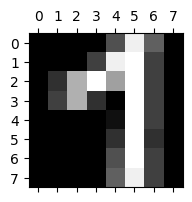

The number is 1


In [5]:
print(digits_df.shape)
print(X_train.shape)
print(y_train.shape)
print(X_train_org[0])

idx = np.random.randint(X_train.shape[0])
dimage = X_train_org[idx].reshape((8, 8))
plt.figure(figsize=(2, 2))
plt.gray()
plt.matshow(dimage, fignum=0)
plt.show()
print('The number is', y_train_num[idx])

### Simple DNN for digit classification

#### Define dense layer class (from Lab 03-3)

In [ ]:
class myDenseLayer:
    def __init__(self, n_out, n_in):
        self.weight = np.empty((n_out, n_in))
        self.bias = np.zeros((n_out))
        self.saved_x = None

    def forward(self, x):   # x: (b, i)

        ### START CODE HERE ###

        # Save input for use in backward pass
        self.saved_x = None
        # Compute linear transformation: z = W * x^T + b  (Eq. 3.28)
        x_lin = None

        ### END CODE HERE ###

        return x_lin

    def backward(self, x):  # x = dJ/dz (b, c)

        ### START CODE HERE ###

        # Compute weight gradient: dJ/dW = (dJ/dz)^T * a^{[l-1]} / N  (Eq. 3.30)
        dw = None
        # Compute bias gradient: dJ/db = mean(dJ/dz)  (Eq. 3.31)
        db = None
        # Propagate gradient to lower layer: W^T * dJ/dz  (Eq. 3.29)
        wdJdz = None

        ### END CODE HERE ###
        
        return dw, db, wdJdz

#### Define backpropagation through activation functions (from Lab 03-3)

In [ ]:
def dJdz_sigmoid(wdJdz_upper, a_l):

    ### START CODE HERE ###

    # Element-wise: dJ/dz = (W^T dJ/dz_upper) * a * (1 - a)  (Eq. 3.29)
    dJdz = None

    ### END CODE HERE ###

    return dJdz

def dJdz_softmax(y_hat, y):

    ### START CODE HERE ###

    # Softmax + cross-entropy gradient: dJ/dz = y_hat - y  (Eq. 3.32)
    dJdz = None

    ### END CODE HERE ###

    return dJdz

### Define batch normalization layer

Batch normalization (Section 4.7) normalizes each feature across the mini-batch and applies learned scale ($\gamma_k$) and shift ($\beta_k$) parameters.

**Forward pass** (Eqs. 4.38–4.41):
$$\mu_k = \frac{1}{N_b} \sum_{i=1}^{N_b} x_k^{(i)}, \quad \sigma_k^2 = \frac{1}{N_b} \sum_{i=1}^{N_b} \left( x_k^{(i)} - \mu_k \right)^2$$
$$\hat{x}_k^{(i)} = \frac{x_k^{(i)} - \mu_k}{\sqrt{\sigma_k^2 + \epsilon}}, \quad y_k^{(i)} = \gamma_k\, \hat{x}_k^{(i)} + \beta_k$$

**Backward pass** (Eqs. 4.42–4.43, 4.49):
$$\frac{\partial J}{\partial \beta_k} = \sum_{i=1}^{N_b} \frac{\partial J}{\partial y_k^{(i)}}, \quad \frac{\partial J}{\partial \gamma_k} = \sum_{i=1}^{N_b} \left( \frac{\partial J}{\partial y_k^{(i)}} \cdot \hat{x}_k^{(i)} \right)$$
$$\frac{\partial J}{\partial x_k^{(i)}} = \frac{\gamma_k}{\sqrt{\sigma_k^2 + \epsilon}} \left( \frac{\partial J}{\partial y_k^{(i)}} - \frac{\hat{x}_k^{(i)}}{N_b} \frac{\partial J}{\partial \gamma_k} - \frac{1}{N_b} \frac{\partial J}{\partial \beta_k} \right)$$

**Inference** (Eq. 4.50): Uses EMA running statistics instead of batch statistics:
$$y_k^{(i)} = \gamma_k \cdot \frac{x_k^{(i)} - \mu_{\text{EMA}}}{\sqrt{\sigma_{\text{EMA}}^2 + \epsilon}} + \beta_k$$

The EMA statistics are updated during training (Eq. 4.51): $\mu_{\text{EMA}} \leftarrow m\, \mu_{\text{EMA}} + (1-m)\, \mu_k$.

In [ ]:
learning_rate = 1.0  # global variable; reassigned in training loop

class myBatchNorm:
    def __init__(self, n_out, batch_size):
        # Trainable parameters (Eq. 4.41)
        self.gamm = np.ones(n_out)
        self.beta = np.zeros(n_out)
        # Non-trainable running statistics for inference (Eq. 4.51)
        self.mean = np.zeros(n_out)   # running mean (mu_EMA)
        self.vari = np.zeros(n_out)   # running variance (sigma^2_EMA)

        # Intermediate values for forward-to-backward transfer
        self.t_mean = np.zeros(n_out)
        self.t_xdif = np.zeros((n_out, batch_size))
        self.t_vari = np.zeros(n_out)
        self.t_stdv = np.zeros(n_out)
        self.t_invs = np.zeros(n_out)
        self.t_xhat = np.zeros((n_out, batch_size))

    def forward(self, x):
        epsilon = 1e-8
        batch_len = x.shape[0]

        ### START CODE HERE ###

        # Compute batch mean: mu_k = (1/N_b) * sum(x_k)  (Eq. 4.38)
        self.t_mean = None
        # Compute deviation from mean: x - mu
        self.t_xdif = None
        # Compute batch variance: sigma_k^2 = (1/N_b) * sum((x_k - mu_k)^2)  (Eq. 4.39)
        self.t_vari = None
        # Compute standard deviation with epsilon for numerical stability
        self.t_stdv = None
        # Compute inverse standard deviation: 1 / sqrt(sigma^2 + epsilon)
        self.t_invs = None
        # Normalize: x_hat = (x - mu) / sqrt(sigma^2 + epsilon)  (Eq. 4.40)
        self.t_xhat = None
        # Scale and shift: y = gamma * x_hat + beta  (Eq. 4.41)
        xout = None

        ### END CODE HERE ###

        return xout

    def backward(self, x):  # x = dJ/dy
        momentum = 0.9  # EMA momentum for running statistics
        batch_len = x.shape[0]

        ### START CODE HERE ###

        # Compute dJ/dbeta = sum(dJ/dy)  (Eq. 4.43)
        dJdb = None
        # Compute dJ/dgamma = sum(dJ/dy * x_hat)  (Eq. 4.42)
        dJdg = None
        # Compute dJ/dx using simplified form  (Eq. 4.49)
        dJdx = None

        # Update gamma and beta using gradient descent
        self.beta = None
        self.gamm = None
        # Update running statistics via EMA  (Eq. 4.51)
        self.mean = None
        self.vari = None

        ### END CODE HERE ###

        return dJdx

    def predict(self, x):
        epsilon = 1e-8

        ### START CODE HERE ###

        # Normalize using EMA statistics: x_hat = (x - mu_EMA) / sqrt(sigma^2_EMA + eps)  (Eq. 4.50)
        x = None
        # Scale and shift: y = gamma * x_hat + beta
        x = None

        ### END CODE HERE ###

        return x

In [9]:
np.random.seed(1)
bn = myBatchNorm(3, 7)
a = bn.forward(np.random.randn(7, 3))
b = bn.backward(np.random.randn(7, 3))
c = bn.predict(np.random.randn(7, 3))
print('forward:\n', a[0:3])
print('backward:\n', b[0:3])
print('predict:\n', c[0:3])
res = [a[0:3], b[0:3], c[0:3]]
exp = [[[ 1.41726481, -0.96839351,  0.21649074],
        [-1.08277462,  0.93413175, -1.34749376],
        [ 1.52892061, -1.16087947,  0.96367092]],
       [[ 0.98604152,  1.06920658,  0.27447564],
        [ 1.07963509, -0.40311355,  0.04751336],
        [-0.95656473, -0.49465193,  0.14398055]],
       [[ 0.72592995, 19.03321851, -1.21365873],
        [ 0.73705164,  2.96814124, -4.91310599],
        [ 0.81349166,  7.52902385, -1.66378185]]]
print('test passed.') if np.allclose(res, exp) else print('test failed.')

forward:
 [[ 1.41726481 -0.96839351  0.21649074]
 [-1.08277462  0.93413175 -1.34749376]
 [ 1.52892061 -1.16087947  0.96367092]]
backward:
 [[ 0.98604152  1.06920658  0.27447564]
 [ 1.07963509 -0.40311355  0.04751336]
 [-0.95656473 -0.49465193  0.14398055]]
predict:
 [[ 0.72592995 19.03321851 -1.21365873]
 [ 0.73705164  2.96814124 -4.91310599]
 [ 0.81349166  7.52902385 -1.66378185]]
test passed.


**Expected output:**
```
forward:
 [[ 1.41726481 -0.96839351  0.21649074]
 [-1.08277462  0.93413175 -1.34749376]
 [ 1.52892061 -1.16087947  0.96367092]]
backward:
 [[ 0.98604152  1.06920658  0.27447564]
 [ 1.07963509 -0.40311355  0.04751336]
 [-0.95656473 -0.49465193  0.14398055]]
predict:
 [[ 0.72592995 19.03321851 -1.21365873]
 [ 0.73705164  2.96814124 -4.91310599]
 [ 0.81349166  7.52902385 -1.66378185]]
```

#### Create a NN model and check matrix dimensions

The architecture is: Dense → BN → Sigmoid → Dense → BN → Sigmoid → Dense → Softmax. Batch normalization is placed between the linear transformation and the activation function.

In [10]:
n_inputs  = 64
n_hidden1 = 80
n_hidden2 = 70
n_classes = 10
n_batch = 64      # batch size

l1 = myDenseLayer(n_hidden1, n_inputs)
b1 = myBatchNorm(n_hidden1, n_batch)
l2 = myDenseLayer(n_hidden2, n_hidden1)
b2 = myBatchNorm(n_hidden2, n_batch)
l3 = myDenseLayer(n_classes, n_hidden2)

layers = [l1, b1, l2, b2, l3]

print(X_train.shape, y_train.shape)
print(l1.weight.shape, l1.bias.shape)
print(l2.weight.shape, l2.bias.shape)
print(l3.weight.shape, l3.bias.shape)

(1437, 64) (1437, 10)
(80, 64) (80,)
(70, 80) (70,)
(10, 70) (10,)


**Expected output:**
```
(1437, 64) (1437, 10)
(80, 64) (80,)
(70, 80) (70,)
(10, 70) (10,)
```

#### Define training functions with batch normalization

In `my_forward`, each hidden layer follows the sequence: Dense → BN (`forward`) → Sigmoid. In `my_backward`, the gradient flows in reverse: Sigmoid derivative → BN (`backward`) → Dense. During loss evaluation and prediction, BN uses `predict` (EMA statistics) instead of `forward` (batch statistics).

In [ ]:
def my_forward(layers, X_in):
    l1, b1, l2, b2, l3 = layers

    ### START CODE HERE ###

    # Layer 1: Dense → BN (batch stats) → Sigmoid
    x_1 = None
    h_1 = None
    a_1 = None

    # Layer 2: Dense → BN (batch stats) → Sigmoid
    x_2 = None
    h_2 = None
    a_2 = None

    # Layer 3: Dense → Softmax (no BN on output layer)
    a_3 = None

    ### END CODE HERE ###

    return a_1, a_2, a_3

def my_backward(layers, a_1, a_2, a_3, y_true):
    l1, b1, l2, b2, l3 = layers

    ### START CODE HERE ###

    # Layer 3 backprop (softmax + cross-entropy)
    dw_3, db_3, wdJdz_3 = None
    # Layer 2 backprop: sigmoid derivative → BN backward → Dense
    dJdz_2 = None
    dJdx_2 = None
    dw_2, db_2, wdJdz_2 = None
    # Layer 1 backprop: sigmoid derivative → BN backward → Dense
    dJdz_1 = None
    dJdx_1 = None
    dw_1, db_1, _ = None

    ### END CODE HERE ###

    d_1 = [dw_1, db_1]
    d_2 = [dw_2, db_2]
    d_3 = [dw_3, db_3]

    return d_1, d_2, d_3

def my_loss(layers, X_in, y_true):
    l1, b1, l2, b2, l3 = layers

    ### START CODE HERE ###

    # Forward pass using EMA statistics (inference mode)
    x_1 = None
    h_1 = None
    a_1 = None
    x_2 = None
    h_2 = None
    a_2 = None
    a_3 = None
    # Cross-entropy loss  (Eq. 3.16)
    loss = None

    ### END CODE HERE ###

    return loss

def my_predict(layers, X_in):
    l1, b1, l2, b2, l3 = layers

    ### START CODE HERE ###

    # Forward pass using EMA statistics (inference mode)
    x_1 = None
    h_1 = None
    a_1 = None
    x_2 = None
    h_2 = None
    a_2 = None
    a_3 = None
    pred = None

    ### END CODE HERE ###
    
    return pred

#### Define optimizers (from Lab 04-1)

These optimizers update only the dense layer weights. The BN parameters ($\gamma$, $\beta$) are updated directly inside `myBatchNorm.backward()`.

In [ ]:
class myOptParam:
    def __init__(self, n_out, n_in):
        self.W_dt = np.zeros((n_out, n_in))
        self.B_dt = np.zeros(n_out)
        self.W_mt = np.zeros((n_out, n_in))
        self.B_mt = np.zeros(n_out)
        self.W_vt = np.zeros((n_out, n_in))
        self.B_vt = np.zeros(n_out)

def my_optimizer(lyr, opt, W_grad, B_grad, solver='sgd', learning_rate=0.01, iter=1):
    epsilon = 1e-8
    alpha = eta = learning_rate

    if iter == 0:
        print('iteration should start from 1.')

    if solver == 'sgd':
        W_dlt = alpha * W_grad
        B_dlt = alpha * B_grad
    elif solver == 'momentum':
        gamma = 0.9
        ### START CODE HERE ###
        pass
        ### END CODE HERE ###
    elif solver == 'adagrad':
        ### START CODE HERE ###
        pass
        ### END CODE HERE ###
    elif solver == 'rmsprop':
        beta2 = 0.9
        ### START CODE HERE ###
        pass
        ### END CODE HERE ###
    elif solver == 'adam':
        beta1, beta2 = 0.9, 0.99
        ### START CODE HERE ###
        pass
        ### END CODE HERE ###
    else:
        print('optimizer error')

    lyr.weight = lyr.weight - W_dlt
    lyr.bias = lyr.bias - B_dlt

    return

#### Create optimizer parameters

In [13]:
o1 = myOptParam(n_hidden1, n_inputs)
o2 = myOptParam(n_hidden2, n_hidden1)
o3 = myOptParam(n_classes, n_hidden2)

#### Weight initialization

Supports standard normal, uniform, Xavier/Glorot (Eqs. 4.20–4.21), and He/Kaiming (Eqs. 4.22–4.23) initialization.

In [14]:
def my_initializer(lyr, pdf='normal'):
    (fan_out, fan_in) = w_shape = lyr.weight.shape
    if pdf == 'normal':
        lyr.weight = np.random.randn(*w_shape)
    elif pdf == 'uniform':
        lyr.weight = np.random.uniform(-1, 1, size=w_shape)
    elif pdf == 'xavier_normal':           # Xavier/Glorot normal  (Eq. 4.20)
        lyr.weight = np.random.randn(*w_shape) * np.sqrt(2 / (fan_out + fan_in))
    elif pdf == 'xavier_uniform':          # Xavier/Glorot uniform  (Eq. 4.21)
        a = np.sqrt(6 / (fan_out + fan_in))
        lyr.weight = np.random.uniform(-a, a, size=w_shape)
    elif pdf == 'he_normal':               # He/Kaiming normal  (Eq. 4.22)
        lyr.weight = np.random.randn(*w_shape) * np.sqrt(2 / fan_in)
    elif pdf == 'he_uniform':              # He/Kaiming uniform  (Eq. 4.23)
        a = np.sqrt(6 / fan_in)
        lyr.weight = np.random.uniform(-a, a, size=w_shape)
    else:
        print('initializer error')
    return

np.random.seed(1)
weight_init = 'normal'

my_initializer(l1, pdf=weight_init)
my_initializer(l2, pdf=weight_init)
my_initializer(l3, pdf=weight_init)

### Training the neural network model

Train the 3-layer model with batch normalization. The global `learning_rate` variable is used by `myBatchNorm.backward()` to update $\gamma$ and $\beta$.

In [15]:
# optimizer settings: 'sgd', 'momentum', 'adagrad', 'rmsprop', 'adam'
optimizer = 'sgd'
learning_rate = alpha = 1e-2      # learning rate (also used by BN backward)
lmbda = 1e-3      # L2 regularization coefficient (not used in this exercise)
dpout = 0.5       # dropout rate (not used in this exercise)

In [ ]:
n_epochs = 1000

for epoch in range(n_epochs):

    batches = create_mini_batches(X_train, y_train, batch_size=n_batch)
    for one_batch in batches:
        X_mini, y_mini = one_batch
        batch_len = X_mini.shape[0]

        # Forward pass (BN uses batch statistics)
        a_1, a_2, a_3 = my_forward(layers, X_mini)

        # Backward pass (BN updates gamma, beta, and EMA stats internally)
        d_1, d_2, d_3 = my_backward(layers, a_1, a_2, a_3, y_mini)

        dw_1, db_1 = d_1
        dw_2, db_2 = d_2
        dw_3, db_3 = d_3

        # Update dense layer weights and biases
        my_optimizer(l1, o1, dw_1, db_1, solver=optimizer, learning_rate=alpha)
        my_optimizer(l2, o2, dw_2, db_2, solver=optimizer, learning_rate=alpha)
        my_optimizer(l3, o3, dw_3, db_3, solver=optimizer, learning_rate=alpha)

    if ((epoch + 1) % 100 == 0):
        loss_J = my_loss(layers, X_train, y_train)
        print('Epoch: %4d,  loss: %10.8f' % (epoch + 1, loss_J))

Epoch:  100,  loss: 0.22718722
Epoch:  200,  loss: 0.14817410
Epoch:  300,  loss: 0.10880295
Epoch:  400,  loss: 0.08434341
Epoch:  500,  loss: 0.07176789
Epoch:  600,  loss: 0.05557247
Epoch:  700,  loss: 0.04659045
Epoch:  800,  loss: 0.04011177
Epoch:  900,  loss: 0.03344257
Epoch: 1000,  loss: 0.02882086


In [17]:
res = np.concatenate((l1.weight[0:3, 0:5], l2.weight[0:3, 0:5], l3.weight[0:3, 0:5]), axis=0)
print(res)
exp = [[ 1.62434536, -0.58121962, -0.58087244, -1.05293763,  0.90413781],
       [ 0.48851815, -0.065168,    1.11903214,  1.53231598,  2.20557957],
       [-1.19926803,  0.85871807, -0.15786691, -0.63195506, -1.26754238],
       [-0.32792985, -0.43310925,  1.82541231, -0.86591151,  0.28477119],
       [-0.14580148, -1.67475747, -0.57248729,  0.5838528,   0.14092727],
       [-1.21429301, -0.44790454,  1.02734289,  1.27972934, -1.07097445],
       [-1.93787635,  0.72082979,  1.5502533,   0.42645534, -0.09665872],
       [-0.3768621,   0.24341344,  1.45537954, -1.46876679,  1.12185764],
       [-0.44848016, -0.23479824,  0.17030664, -0.75588797,  0.64638018]]
if weight_init == 'normal':
    print('test passed.') if np.allclose(res, exp) else print('test failed.')
else:
    print('to verify your code, set initializer to ' + '\033[1m' + 'normal' + '\033[0m')

[[ 1.62434536 -0.58121962 -0.58087244 -1.05293763  0.90413781]
 [ 0.48851815 -0.065168    1.11903214  1.53231598  2.20557957]
 [-1.19926803  0.85871807 -0.1578669  -0.63195506 -1.26754238]
 [-0.32792985 -0.43310925  1.82541231 -0.86591151  0.28477119]
 [-0.14580148 -1.67475747 -0.57248729  0.5838528   0.14092727]
 [-1.21429301 -0.44790454  1.02734289  1.27972934 -1.07097445]
 [-1.93787635  0.72082979  1.5502533   0.42645534 -0.09665872]
 [-0.37686211  0.24341344  1.45537954 -1.46876679  1.12185764]
 [-0.44848016 -0.23479824  0.17030664 -0.75588797  0.64638018]]
test passed.


### Evaluate model performance

In [18]:
from sklearn.metrics import accuracy_score

y_pred = my_predict(layers, X_test)

accuracy_score(y_pred, y_test)

0.9583333333333334

### Comparison with scikit-learn

Compare with `MLPClassifier` using SGD and logistic activation. Note that scikit-learn's `MLPClassifier` does not support batch normalization.

In [19]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(80, 70,), activation='logistic', solver='sgd',
                    alpha=0.01, learning_rate_init=0.01, max_iter=1000)

# Training the model
mlp.fit(X_train, y_train_num)

# Evaluate on test set
s_pred = mlp.predict(X_test)
accuracy_score(s_pred, y_test)

0.975

### Test model with a random sample

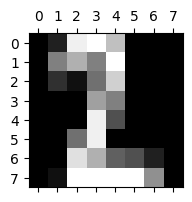

My prediction is 2
sk prediction is 2
Actual number is 2


In [20]:
idx = np.random.randint(X_test.shape[0])
dimage = X_test_org[idx].reshape((8, 8))
plt.figure(figsize=(2, 2))
plt.gray()
plt.matshow(dimage, fignum=0)
plt.show()

X_input = np.expand_dims(X_test[idx], 0)

y_pred = my_predict(layers, X_input)

s_pred = mlp.predict(X_input)

print('My prediction is ' + str(y_pred[0]))
print('sk prediction is ' + str(s_pred[0]))
print('Actual number is ' + str(y_test[idx]))

(c) 2026 S. W. Lee